<a href="https://colab.research.google.com/github/abdulmusai/Decision-Tree-Classification-Airline-Customer-Satisfaction/blob/main/Decision_Tree_Classification_%E2%80%93_Airline_Customer_Satisfaction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ==========================================
# 1. SETUP AND DATA LOADING
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score

# Load the dataset
df = pd.read_csv('/content/drive/MyDrive/Invistico_Airline.csv')
print(f"Dataset Shape: {df.shape}")
print(df.info())

Dataset Shape: (129880, 22)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129880 entries, 0 to 129879
Data columns (total 22 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   satisfaction                       129880 non-null  object 
 1   Customer Type                      129880 non-null  object 
 2   Age                                129880 non-null  int64  
 3   Type of Travel                     129880 non-null  object 
 4   Class                              129880 non-null  object 
 5   Flight Distance                    129880 non-null  int64  
 6   Seat comfort                       129880 non-null  int64  
 7   Departure/Arrival time convenient  129880 non-null  int64  
 8   Food and drink                     129880 non-null  int64  
 9   Gate location                      129880 non-null  int64  
 10  Inflight wifi service              129880 non-null  int64  
 11  Inflight en

In [5]:
# ==========================================
# 2. DATA PREPROCESSING & PIPELINE SETUP
# ==========================================
# Handle missing values in target or features if any
# 'Arrival Delay in Minutes' often contains missing values; we'll impute with median
df['Arrival Delay in Minutes'] = df['Arrival Delay in Minutes'].fillna(df['Arrival Delay in Minutes'].median())

# Separate Features (X) and Target (y)
X = df.drop(columns=['satisfaction'])
y = df['satisfaction'].map({'satisfied': 1, 'dissatisfied': 0}) # Encode target to binary

# Identify column types
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

print(f"\nCategorical columns: {categorical_cols}")
print(f"Numeric columns: {numeric_cols}")

# Create preprocessor using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols), # Scaling is vital for Logistic Regression
        ('cat', OneHotEncoder(drop='first'), categorical_cols) # drop='first' avoids multicollinearity
    ])

# Split the data into Train and Test sets (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)



Categorical columns: ['Customer Type', 'Type of Travel', 'Class']
Numeric columns: ['Age', 'Flight Distance', 'Seat comfort', 'Departure/Arrival time convenient', 'Food and drink', 'Gate location', 'Inflight wifi service', 'Inflight entertainment', 'Online support', 'Ease of Online booking', 'On-board service', 'Leg room service', 'Baggage handling', 'Checkin service', 'Cleanliness', 'Online boarding', 'Departure Delay in Minutes', 'Arrival Delay in Minutes']


In [7]:
# ==========================================
# 3. HYPERPARAMETER TUNING WITH GRIDSEARCHCV
# ==========================================
# Build a pipeline with the preprocessor and Decision Tree
dt_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=42))
])

# Define the parameter grid to prevent overfitting
param_grid = {
    'classifier__max_depth': [3, 5, 7, 10, 15],
    'classifier__min_samples_split': [10, 20, 50],
    'classifier__min_samples_leaf': [5, 10, 20]
}

print("\nRunning GridSearchCV for Decision Tree...")
grid_search = GridSearchCV(dt_pipeline, param_grid, cv=5, scoring='f1', n_jobs=-1)
grid_search.fit(X_train, y_train)

best_dt_model = grid_search.best_estimator_

# FIX: Changed from best_params__ to best_params_
print(f"Best Hyperparameters: {grid_search.best_params_}")


Running GridSearchCV for Decision Tree...
Best Hyperparameters: {'classifier__max_depth': 15, 'classifier__min_samples_leaf': 5, 'classifier__min_samples_split': 20}



Decision Tree Test F1-Score: 0.9441

Classification Report (Decision Tree):
              precision    recall  f1-score   support

           0       0.92      0.95      0.93     11759
           1       0.96      0.93      0.94     14217

    accuracy                           0.94     25976
   macro avg       0.94      0.94      0.94     25976
weighted avg       0.94      0.94      0.94     25976



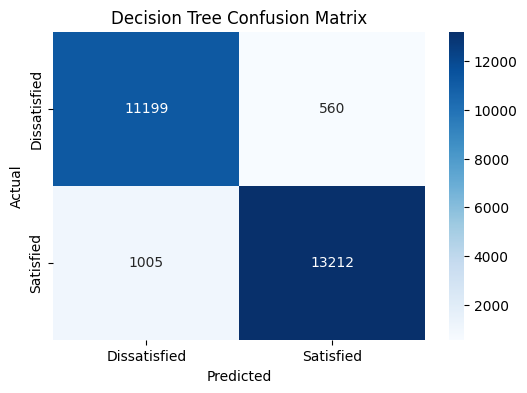

In [8]:
# ==========================================
# 4. MODEL EVALUATION (DECISION TREE)
# ==========================================
# Predictions
y_pred_dt = best_dt_model.predict(X_test)

# Metrics
dt_f1 = f1_score(y_test, y_pred_dt)
print(f"\nDecision Tree Test F1-Score: {dt_f1:.4f}")
print("\nClassification Report (Decision Tree):")
print(classification_report(y_test, y_pred_dt))

# Confusion Matrix Plot
cm_dt = confusion_matrix(y_test, y_pred_dt)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues', xticklabels=['Dissatisfied', 'Satisfied'], yticklabels=['Dissatisfied', 'Satisfied'])
plt.title('Decision Tree Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

/tmp/ipykernel_3569/3476338109.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_imp_df.head(10), palette='viridis')


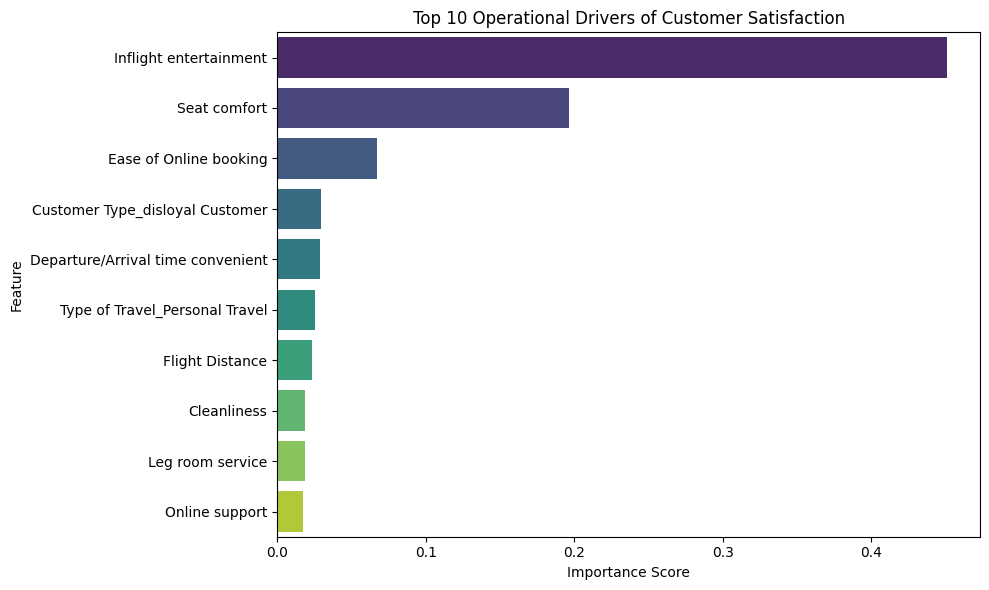

In [9]:
# ==========================================
# 5. FEATURE IMPORTANCE EXTRACTION
# ==========================================
# Get feature names after OneHotEncoding transformation
encoded_cat_features = best_dt_model.named_steps['preprocessor'].transformers_[1][1].get_feature_names_out(categorical_cols).tolist()
all_features = numeric_cols + encoded_cat_features

# Extract importances
importances = best_dt_model.named_steps['classifier'].feature_importances_

# Create a DataFrame for ranking
feature_imp_df = pd.DataFrame({'Feature': all_features, 'Importance': importances}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_imp_df.head(10), palette='viridis')
plt.title('Top 10 Operational Drivers of Customer Satisfaction')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

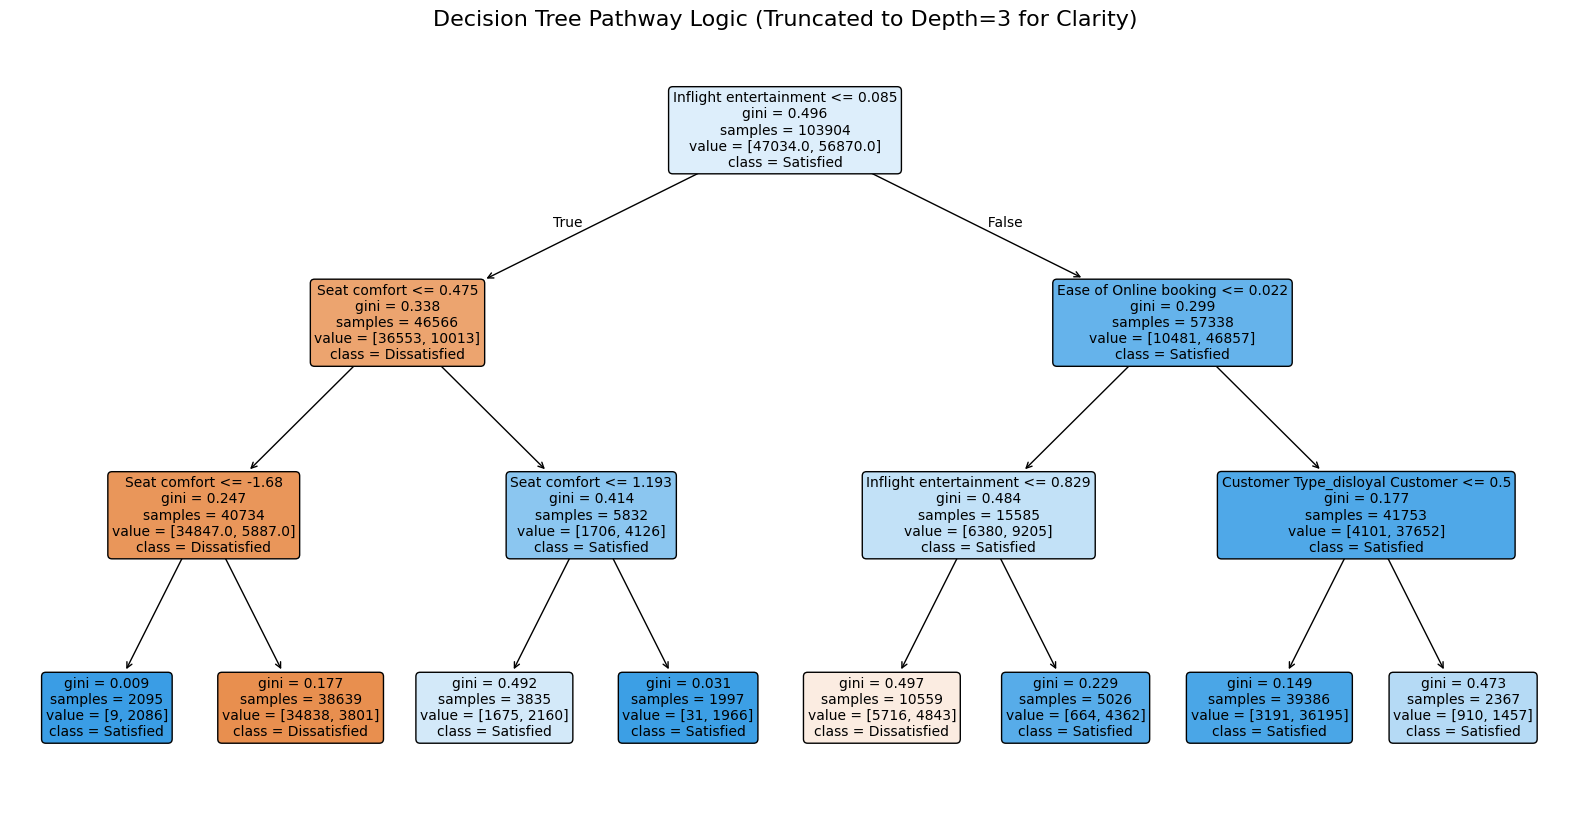

In [10]:
# ==========================================
# 6. DECISION PATHWAY VISUALIZATION
# ==========================================
# Note: Plotting a deep tree is illegible. We'll train a small shallow tree just for visualization purposes.
plt.figure(figsize=(20, 10))
visual_tree = DecisionTreeClassifier(max_depth=3, random_state=42)
visual_tree.fit(best_dt_model.named_steps['preprocessor'].transform(X_train), y_train)

plot_tree(visual_tree, feature_names=all_features, class_names=['Dissatisfied', 'Satisfied'], filled=True, rounded=True, fontsize=10)
plt.title("Decision Tree Pathway Logic (Truncated to Depth=3 for Clarity)", fontsize=16)
plt.show()

In [11]:
# ==========================================
# 7. COMPARISON WITH LOGISTIC REGRESSION
# ==========================================
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

lr_pipeline.fit(X_train, y_train)
y_pred_lr = lr_pipeline.predict(X_test)
lr_f1 = f1_score(y_test, y_pred_lr)

print("\n" + "="*40)
print(f"Logistic Regression Test F1-Score: {lr_f1:.4f}")
print("="*40)
print(classification_report(y_test, y_pred_lr))


Logistic Regression Test F1-Score: 0.8437
              precision    recall  f1-score   support

           0       0.81      0.81      0.81     11759
           1       0.84      0.84      0.84     14217

    accuracy                           0.83     25976
   macro avg       0.83      0.83      0.83     25976
weighted avg       0.83      0.83      0.83     25976

